# Stock Price Predictor
A machine learning project that predicts AAPL stock price direction (up or down) using historical price data and technical indicators.

**Models used:** Random Forest, Logistic Regression, XGBoost  
**Data:** AAPL stock, 2020-2024  
**Tools:** Python, pandas, scikit-learn, yfinance, matplotlib

## 1. Data Collection
Using Yahoo Finance (yfinance) to fetch historical AAPL stock data from January 2020 to January 2024, giving us 1,006 trading days of closing prices, volume, and daily high/low values.

In [189]:
import yfinance as yf

df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
print(df.shape)

[*********************100%***********************]  1 of 1 completed

(1006, 5)


In [190]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


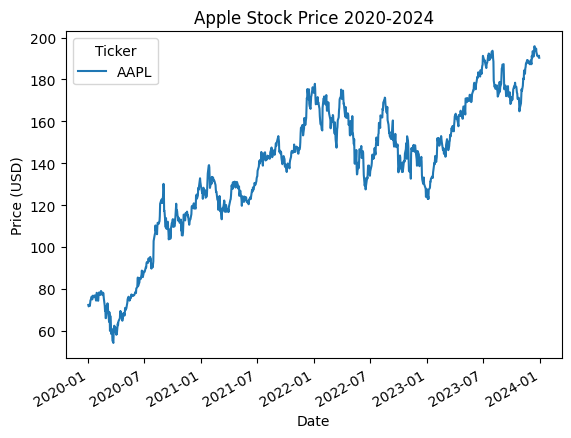

In [191]:
import matplotlib.pyplot as plt

df["Close"].plot()
plt.title("Apple Stock Price 2020-2024")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.show()

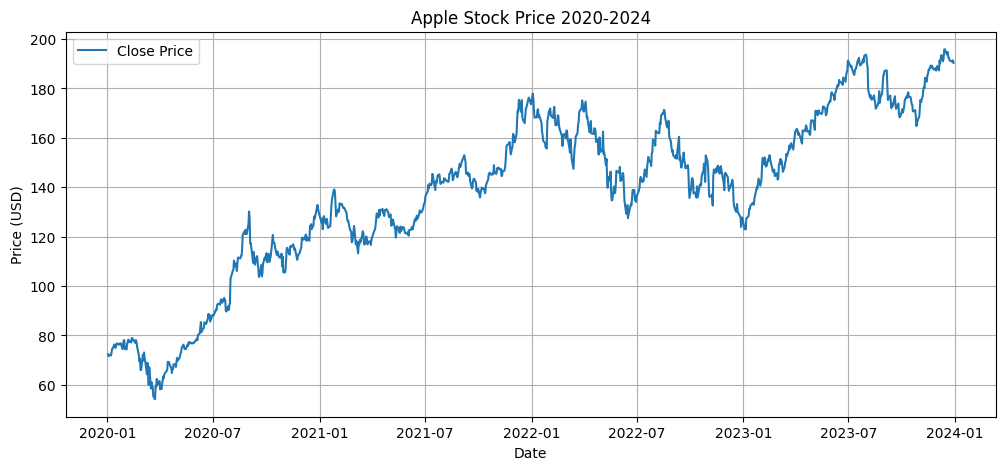

In [192]:
plt.figure(figsize=(12, 5))
plt.plot(df["Close"], label="Close Price")
plt.title("Apple Stock Price 2020-2024")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

## 3. Feature Engineering
Creating new features from the raw price data to give our models meaningful signals. Raw price levels alone are insufficient for predicting direction — we need features that capture momentum, trend, and volatility.

- **MA7** — 7-day moving average. Captures short-term trend
- **MA21** — 21-day moving average. Captures longer-term trend  
- **Volatility** — 7-day rolling standard deviation. Measures price stability
- **MA_diff** — MA7 minus MA21. Captures the gap between short and long term trends
- **MA_cross** — 1 if MA7 > MA21 (golden cross), 0 otherwise
- **Momentum** — Close price minus Close price 5 days ago
- **Volume_change** — Percentage change in volume over 5 days

In [194]:
df["MA7"] = df["Close"].rolling(window=7).mean()
df["MA21"] = df["Close"].rolling(window=21).mean()
df.head(2)

Price,Close,High,Low,Open,Volume,MA7,MA21
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800,NaN,NaN


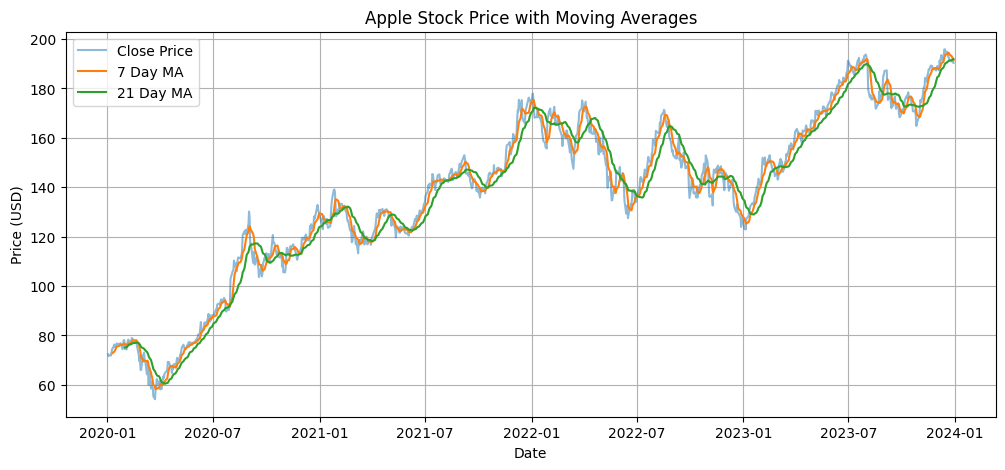

In [195]:
plt.figure(figsize=(12, 5))
plt.plot(df["Close"], label="Close Price", alpha=0.5)
plt.plot(df["MA7"], label="7 Day MA")
plt.plot(df["MA21"], label="21 Day MA")
plt.title("Apple Stock Price with Moving Averages")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

In [196]:
df["Volatility"] = df["Close"].rolling(7).std()
df.head(10)

Price,Close,High,Low,Open,Volume,MA7,MA21,Volatility
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,NaN
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800,NaN,NaN,NaN
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,NaN
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,NaN,NaN,NaN
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN,NaN,NaN
2020-01-09,74.568794,74.761457,73.742742,73.993202,170108400,NaN,NaN,NaN
2020-01-10,74.737358,75.300911,74.236431,74.802387,140644800,72.907399,NaN,1.269630
2020-01-13,76.334106,76.360602,74.934873,75.052886,121532000,73.478860,NaN,1.770084


## 3. Target Variable
Creating a binary classification target: 1 if tomorrow's closing price is higher than today's (stock goes up), 0 if it goes down. This converts our problem from price prediction (regression) to direction prediction (classification).

In [197]:
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
df["Target"].value_counts()

Target
1    528
0    478
Name: count, dtype: int64

## 4. Preprocessing
Dropping NaN rows produced by rolling window calculations, then splitting data chronologically into training (2020-2022) and test (2023-2024) sets. A time-based split is essential to avoid data leakage — randomly splitting would allow future data to leak into training, producing misleadingly good results that would fail in real use.

In [199]:
train = df.loc["2020-01-01":"2022-12-31"]
test = df.loc["2023-01-01":"2024-01-01"]
print(train.shape)
print(test.shape)

(756, 9)
(250, 9)


In [200]:
X_train = train[["MA7", "MA21", "Volatility"]]
y_train = train["Target"]
X_test = test[["MA7", "MA21", "Volatility"]]
y_test = test["Target"]
print(X_train.shape)
print(X_test.shape)

(756, 3)
(250, 3)


## 5. Model Training & Evaluation
Training three different machine learning models and comparing their performance using precision, recall, F1 score and accuracy. 

- **Precision** — of all predicted ups, how many were actually up?
- **Recall** — of all actual ups, how many did the model catch?
- **F1 Score** — the balance between precision and recall

### 5a. Random Forest Classifier
An ensemble of 100 decision trees, each trained on a random subset of data. Predictions are made by majority vote across all trees.

In [201]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [202]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.51


In [203]:
df["MA_diff"] = df["MA7"] - df["MA21"]
df["MA_cross"] = (df["MA7"] > df["MA21"]).astype(int)
df["Momentum"] = df["Close"] - df["Close"].shift(5)
df["Volume_change"] = df["Volume"].pct_change(5)
df = df.dropna()
print(df.head(10))

Price           Close       High        Low       Open     Volume        MA7  \
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL              
Date                                                                           
2020-01-31  74.539886  77.711639  74.246071  77.290183  199588400  76.443496   
2020-02-03  74.335175  75.498389  72.784217  73.285144  173788400  76.079839   
2020-02-04  76.789253  76.979512  75.532110  75.936706  136616400  76.098415   
2020-02-05  77.415428  78.212581  76.813348  77.913945  118826800  76.528472   
2020-02-06  78.320938  78.323349  77.128825  77.685146  105425600  76.787193   
2020-02-07  77.256355  78.069884  76.766307  77.821239  117684000  76.665039   
2020-02-10  77.623299  77.623299  75.764496  75.844156  109348800  76.611476   
2020-02-11  77.154984  78.190607  76.937722  78.118189   94323200  76.985062   
2020-02-12  78.987236  78.992061  77.603991  77.603991  113730400  77.649642   
2020-02-13  78.424744  78.750640  78.057

In [204]:
train = df.loc["2020-01-01":"2022-12-31"]
test = df.loc["2023-01-01":"2024-01-01"]
print(train.shape)
print(test.shape)

X_train = train[["MA7", "MA21", "Volatility", "MA_diff", "MA_cross", "Momentum", "Volume_change"]]
y_train = train["Target"]
X_test = test[["MA7", "MA21", "Volatility", "MA_diff", "MA_cross", "Momentum", "Volume_change"]]
y_test = test["Target"]
print(X_train.shape)
print(X_test.shape)

(736, 13)
(250, 13)
(736, 7)
(250, 7)


In [205]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [206]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.49


In [207]:
print(X_train.isna().sum())

Price          Ticker
MA7                      0
MA21                     0
Volatility               0
MA_diff                  0
MA_cross                 0
Momentum                 0
Volume_change            0
dtype: int64


In [208]:
print(y_test.value_counts())
predictions_series = pd.Series(predictions)
print(predictions_series.value_counts())

Target
1    140
0    110
Name: count, dtype: int64
0    181
1     69
Name: count, dtype: int64


In [209]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

[[82 28]
 [99 41]]


In [210]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.45      0.75      0.56       110
           1       0.59      0.29      0.39       140

    accuracy                           0.49       250
   macro avg       0.52      0.52      0.48       250
weighted avg       0.53      0.49      0.47       250



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.46      0.67      0.54       110
           1       0.59      0.37      0.46       140

    accuracy                           0.50       250
   macro avg       0.52      0.52      0.50       250
weighted avg       0.53      0.50      0.49       250



In [215]:
from xgboost import XGBClassifier
xg_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xg_model.fit(X_train, y_train)
xg_predictions = xg_model.predict(X_test)
print(classification_report(y_test, xg_predictions))

              precision    recall  f1-score   support

           0       0.45      0.63      0.52       110
           1       0.57      0.39      0.47       140

    accuracy                           0.50       250
   macro avg       0.51      0.51      0.49       250
weighted avg       0.52      0.50      0.49       250



## 6. Conclusion
All three models achieved approximately 49-50% accuracy — barely better than random guessing. This is consistent with the genuine difficulty of stock market direction prediction. Even with carefully engineered features and three different ML approaches, the market's complexity cannot be captured by technical indicators alone.

| Model | Accuracy | Class 1 F1 | Class 1 Recall |
|-------|----------|------------|----------------|
| Random Forest | 0.49 | 0.39 | 0.29 |
| Logistic Regression | 0.50 | 0.46 | 0.37 |
| XGBoost | 0.50 | 0.47 | 0.39 |

**Key learnings:**
- Feature engineering is more important than model choice
- Time-based splitting is essential for financial data to avoid data leakage
- Honest evaluation matters — a 50% result on stock prediction is realistic, not a failure